# **Question Answering Model for SQuAD dataset**

### Import needed library dependencies 

In [11]:
import json 
import torch

import pandas as pd
import torch.nn as nn

from torchtext.legacy.data import Dataset
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report

### Mount GPU resources (if available)

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using {device} device')
torch.cuda.empty_cache()

Using cuda device


### Install transformers

In [12]:
!pip install transformers

In [14]:
from transformers import DistilBertTokenizerFast, DistilBertForQuestionAnswering, BertTokenizerFast, BertForQuestionAnswering
from transformers import AdamW

### Reading training dataset from json

We do also remove the "version" field since we do not need it at all

In [5]:
df = pd.read_json('../input/squad-20/train-v2.0.json')
del df["version"]
df.head()

,data
0,"{'title': 'Beyoncé', 'paragraphs': [{'qas': [{..."
1,"{'title': 'Frédéric_Chopin', 'paragraphs': [{'..."
2,{'title': 'Sino-Tibetan_relations_during_the_M...
3,"{'title': 'IPod', 'paragraphs': [{'qas': [{'qu..."
4,{'title': 'The_Legend_of_Zelda:_Twilight_Princ...


### Reading evaluation dataset from json

In [6]:
df_test = pd.read_json('../input/squad-20/dev-v2.0.json')
del df_test["version"]
df_test.head()

,data
0,"{'title': 'Normans', 'paragraphs': [{'qas': [{..."
1,"{'title': 'Computational_complexity_theory', '..."
2,"{'title': 'Southern_California', 'paragraphs':..."
3,"{'title': 'Sky_(United_Kingdom)', 'paragraphs'..."
4,"{'title': 'Victoria_(Australia)', 'paragraphs'..."


### Prepare data 

We extract only the fields we need for the question/answer task. Thus, function prepare_data extracts the questions, context and answers field from the jsons given as input and returns a dictionary with these three fields: question, context, answer

In [7]:
def prepare_data(df):
    comp_list = []
    contextList = []
    qList = []
    aList = []

    for index, row in df.iterrows():
        for par in row[0]['paragraphs']:
          for qa in par["qas"]:
            for a in qa["answers"]:
              contextList.append(par["context"])
              qList.append(qa["question"])
              aList.append(a)

    return { 'question': qList,
            'context': contextList,
            'answers': aList}

data = prepare_data(df)
test_data = prepare_data(df_test)
data['answers'][:5]

[{'text': 'in the late 1990s', 'answer_start': 269},
 {'text': 'singing and dancing', 'answer_start': 207},
 {'text': '2003', 'answer_start': 526},
 {'text': 'Houston, Texas', 'answer_start': 166},
 {'text': 'late 1990s', 'answer_start': 276}]

### **Update answer start and add answer end field in data**

Function add_end_idx finds  out character position at which the answer ends in the passage. It also corrects answer start and end position if the SQuAD answers are off by one or two characters.

In [8]:
## Function to update answer_start and answer_end 
def add_end_idx(answers, contexts):
    for answer, context in zip(answers, contexts):
        # Your code here
        if answer['answer_start'] is None:
            answer['answer_end'] = None
        else:
            answer_text  = answer['text']
            answer_start = answer['answer_start']
            answer_end   = len(answer_text) + answer_start

            #Sometimes answers are off by a character or two
            if context[answer_start:answer_end] == answer['text']:
                answer['answer_end'] = answer_end
            # If the answer text is off by 1 character
            elif context[answer_start-1:answer_end-1] == answer_text:
                answer['answer_start'] = answer_start - 1
                answer['answer_end'] = answer_end - 1     
            # If the answer text is off by 2 characters
            elif context[answer_start-2:answer_end-2] == answer_text:
                answer['answer_start'] = answer_start - 2
                answer['answer_end'] = answer_end - 2 

In [9]:
add_end_idx(data["answers"], data["context"])
add_end_idx(test_data["answers"], test_data["context"])

In [10]:
data['answers'][:5]

[{'text': 'in the late 1990s', 'answer_start': 269, 'answer_end': 286},
 {'text': 'singing and dancing', 'answer_start': 207, 'answer_end': 226},
 {'text': '2003', 'answer_start': 526, 'answer_end': 530},
 {'text': 'Houston, Texas', 'answer_start': 166, 'answer_end': 180},
 {'text': 'late 1990s', 'answer_start': 276, 'answer_end': 286}]

In [11]:
test_data['answers'][:5]

[{'text': 'France', 'answer_start': 159, 'answer_end': 165},
 {'text': 'France', 'answer_start': 159, 'answer_end': 165},
 {'text': 'France', 'answer_start': 159, 'answer_end': 165},
 {'text': 'France', 'answer_start': 159, 'answer_end': 165},
 {'text': '10th and 11th centuries', 'answer_start': 94, 'answer_end': 117}]

### **Tokenization of context and questions**

In [12]:
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

train = tokenizer(data['context'], data['question'], truncation=True, padding='max_length', max_length=512, return_tensors='pt') 
tokenizer.decode(train['input_ids'][0])[:100]

'[CLS] beyonce giselle knowles - carter ( / biːˈjɒnseɪ / bee - yon - say ) ( born september 4, 1981 )'

In [13]:
test = tokenizer(test_data['context'], test_data['question'], truncation=True, padding='max_length', max_length=512, return_tensors='pt') 
tokenizer.decode(test['input_ids'][0])[:50]

'[CLS] the normans ( norman : nourmands ; french : '

### **Convert answer_start and answer_end fields to tokens**

In [14]:
def add_token_positions(encodings, answers):
    # initialize lists to contain the token indices of answer start/end
    start_positions = []
    end_positions = []
    for i in tqdm(range(len(answers))):
        # append start and end token position using
        start_positions.append(encodings.char_to_token(i, answers[i]['answer_start']))
        end_positions.append(encodings.char_to_token(i, answers[i]['answer_end']))

        # if start position is None, the answer passage has been truncated
        if start_positions[-1] is None:
            start_positions[-1] = tokenizer.model_max_length
        # If the end position cannot be found (char_to_token found space), we shift position until found
        shift = 1
        while end_positions[-1] is None:
            end_positions[-1] = encodings.char_to_token(i, answers[i]['answer_end'] - shift)
            shift += 1
    # update our encodings object with the new token-based start/end positions
    encodings.update({'start_positions': start_positions, 'end_positions': end_positions})

In [15]:
add_token_positions(train, data['answers'])
add_token_positions(test, test_data['answers'])

  0%|          | 0/86821 [00:00<?, ?it/s]

  0%|          | 0/20302 [00:00<?, ?it/s]

### **Create custom Dataset class for SqUAD data**

In [16]:
class CustomDataset(Dataset):
  def __init__(self, encodings, device='cpu'):
    self.device = device
    self.encodings = encodings

  def __len__(self):
    return len(self.encodings.input_ids)

  def __getitem__(self, idx):
        return {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


dataset = CustomDataset(train, device)
eval_dataset = CustomDataset(test, device)

### **Load data and create batches**

In [17]:
pin_memory = False
if(device == 'cuda'):
  pin_memory = True

print(pin_memory)

dataloader = DataLoader(dataset, batch_size=8, shuffle=True, pin_memory=pin_memory)
eval_dataloader = DataLoader(eval_dataset, batch_size=8, shuffle=True, pin_memory=pin_memory)

True


### **Define model parameters**

Here, we define the number of epochs for the model's training process. We also load the model of our choice (in this case *DistilBertForQuestionAnswering* since the time available for trainning was limited) and the optimizer. 

The learning rate that gives better results after some experiments run in smaller parts of the initial dataset is 5e-5, which is actually the bottom threshold most suggest for these kind of qa-models.

In [18]:
N_EPOCHS = 4

net = DistilBertForQuestionAnswering.from_pretrained("distilbert-base-uncased")
for name, param in net.named_parameters():
    if param.requires_grad:
        print(name, param.shape)

LR = 5e-5
optimizer = AdamW(net.parameters(), lr=LR)
net.to(device)

Some weights of the model checkpoint at distilbert-base-uncased were not used when initializing DistilBertForQuestionAnswering: ['vocab_layer_norm.bias', 'vocab_layer_norm.weight', 'vocab_projector.bias', 'vocab_transform.weight', 'vocab_projector.weight', 'vocab_transform.bias']
- This IS expected if you are initializing DistilBertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DistilBertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of DistilBertForQuestionAnswering were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['qa_outputs.bias', 'qa_outputs.weight']
You should probably TRAIN this mode

distilbert.embeddings.word_embeddings.weight torch.Size([30522, 768])
distilbert.embeddings.position_embeddings.weight torch.Size([512, 768])
distilbert.embeddings.LayerNorm.weight torch.Size([768])
distilbert.embeddings.LayerNorm.bias torch.Size([768])
distilbert.transformer.layer.0.attention.q_lin.weight torch.Size([768, 768])
distilbert.transformer.layer.0.attention.q_lin.bias torch.Size([768])
distilbert.transformer.layer.0.attention.k_lin.weight torch.Size([768, 768])
distilbert.transformer.layer.0.attention.k_lin.bias torch.Size([768])
distilbert.transformer.layer.0.attention.v_lin.weight torch.Size([768, 768])
distilbert.transformer.layer.0.attention.v_lin.bias torch.Size([768])
distilbert.transformer.layer.0.attention.out_lin.weight torch.Size([768, 768])
distilbert.transformer.layer.0.attention.out_lin.bias torch.Size([768])
distilbert.transformer.layer.0.sa_layer_norm.weight torch.Size([768])
distilbert.transformer.layer.0.sa_layer_norm.bias torch.Size([768])
distilbert.trans

DistilBertForQuestionAnswering(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0): TransformerBlock(
          (attention): MultiHeadSelfAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
            

### **Train model and Fine Tuning**

In [19]:
train_stats = []

for epoch in range(N_EPOCHS):
  batch_losses = []
  running_loss = 0.0
  i=0

  # Ensure net in training mode
  net.train()
  for i, batch in enumerate(dataloader):
    # Zero out gradients
    optimizer.zero_grad()
    
    input_ids = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    start_positions = batch['start_positions'].to(device)
    end_positions = batch['end_positions'].to(device)

    output = net(input_ids, attention_mask=attention_mask, start_positions=start_positions, end_positions=end_positions)
    
    loss = output[0]
    loss.backward()
    optimizer.step()
    
    # Track loss
    # CE loss
    batch_losses.append(loss.item())
    current_loss = loss.item()
    running_loss += (current_loss - running_loss) / (i + 1)     

  print(f"Epoch {epoch:3}: Loss = {float(running_loss)}")

  train_stats.append(float(running_loss))

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  # Remove the CWD from sys.path while we load stuff.


Epoch   0: Loss = 1.4815239961196727
Epoch   1: Loss = 0.9529497479690582
Epoch   2: Loss = 0.7199760431825889
Epoch   3: Loss = 0.5649817392825905


### Save fine-tuned model 

In [20]:
net.save_pretrained("./bert_qa")

### **Evaluate model with *dev-dataset***

In [21]:
eval_stats = []

for epoch in range(N_EPOCHS):
  batch_losses = []
  prediction = []
  running_loss = 0.0
  i=0  

  # Compute the validation score
  net.to(device)
  net.eval()
  running_loss_val = 0.0
  for i, batch in enumerate(eval_dataloader):
    with torch.no_grad():
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        start_positions = batch['start_positions'].to(device)
        end_positions = batch['end_positions'].to(device)
        y_pred = net(input_ids, attention_mask=attention_mask, start_positions=start_positions, end_positions=end_positions)

        loss = loss = output[0]

        current_loss = loss.item()
        running_loss += (current_loss - running_loss) / (i + 1)

        prediction.append(y_pred)
        i += 1

  print(f"Epoch {epoch:3}: Loss = {float(running_loss)}")
  eval_stats.append(running_loss)

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  # Remove the CWD from sys.path while we load stuff.


Epoch   0: Loss = 0.055452726781368256
Epoch   1: Loss = 0.055452726781368256
Epoch   2: Loss = 0.055452726781368256
Epoch   3: Loss = 0.055452726781368256


### Train and Validation Losses

In [22]:
train_stats_df = pd.DataFrame(list(zip(train_stats, eval_stats)), columns=['train_loss', 'val_loss'])
display(train_stats_df)

,train_loss,val_loss
0,1.481524,0.055453
1,0.952950,0.055453
2,0.719976,0.055453
3,0.564982,0.055453


### Plot of train and validation losses

In the plot below we can see that the training loss looks like a good fit, since it diminishes through the epochs. On the other hand, the much lower and generally flat validation line, indicates that the validation dataset may be easier for the model to predict than the training dataset.

The experiments run focused in three axes:

1. The number of data given as input to the model. This did not really seem to affect its performance for the best. Actually, since the model has less information available to learn from, the evaluation performance does not fair well. Thus we conclude that the more data we feed it, the merrier.

2. The number of entries each batch we feed during the model's training was also under some experimentation. First due to limited resources we could not really experiment with big numbers, and second it was observed that the smaller the batches the better for our model's performance. This is something we already know from theory. Thus, we observe the loss of our model rapidly falling from one epoch to the next.

3. Another parameter that makes the difference is the learning rate. It is suggested in all sources that the learning rate for this kind of problems should be low. Indeed, after trying to train the model with values like 1e-3, 1e-5 and others, we concluded that the best choice was 5e-5. With this value the model has the following curve for its training losses.(x=loss, y=epochs)

<AxesSubplot:>

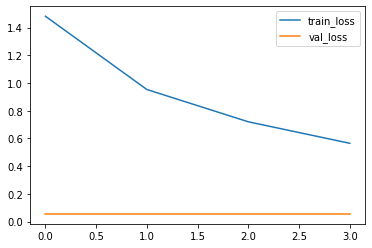

In [23]:
train_stats_df.plot()

*Unfortunately I was not able to run this part, because the runtime available was exceeded :(*

In [7]:
def get_prediction(question, context):
    inputs = tokenizer.encode_plus(question, context, return_tensors='pt')

    outputs = model(**inputs)
    answer_start = torch.argmax(outputs[0])  # get the most likely beginning of answer with the argmax of the score
    answer_end = torch.argmax(outputs[1]) + 1 

    answer = tokenizer.convert_tokens_to_string(tokenizer.convert_ids_to_tokens(inputs['input_ids'][0][answer_start:answer_end]))

    return answer

def normalize_text(s):
  """Removing articles and punctuation, and standardizing whitespace are all typical text processing steps."""
  import string, re

  def remove_articles(text):
    regex = re.compile(r"\b(a|an|the)\b", re.UNICODE)
    return re.sub(regex, " ", text)

  def white_space_fix(text):
    return " ".join(text.split())

  def remove_punc(text):
    exclude = set(string.punctuation)
    return "".join(ch for ch in text if ch not in exclude)

  def lower(text):
    return text.lower()

  return white_space_fix(remove_articles(remove_punc(lower(s))))

def compute_exact_match(prediction, truth):
    return int(normalize_text(prediction) == normalize_text(truth))

def compute_f1(prediction, truth):
  pred_tokens = normalize_text(prediction).split()
  truth_tokens = normalize_text(truth).split()
  
  # if either the prediction or the truth is no-answer then f1 = 1 if they agree, 0 otherwise
  if len(pred_tokens) == 0 or len(truth_tokens) == 0:
    return int(pred_tokens == truth_tokens)
  
  common_tokens = set(pred_tokens) & set(truth_tokens)
  
  # if there are no common tokens then f1 = 0
  if len(common_tokens) == 0:
    return 0
  
  prec = len(common_tokens) / len(pred_tokens)
  rec = len(common_tokens) / len(truth_tokens)
  
  return 2 * (prec * rec) / (prec + rec)
  
def predict_answer(question,answer, context):

  prediction = get_prediction(context,question)
  exact_match_score = compute_exact_match(prediction, answer)
  f1_score = compute_f1(prediction, answer)

  print(f"Question: {question}")
  print(f"Prediction: {prediction}")
  print(f"True Answer: {answer}")
  print(f"EM: {exact_match_score} \t F1: {f1_score}\n")

In [ ]:
questions = ["In what country is Normandy located?", 
             "When were the Normans in Normandy?",
             "From which countries did the Norse originate?",
             "Who was the Norse leader?",
             "What century did the Normans first gain their separate identity?"]

answers = ["France", 
           "10th and 11th centuries", 
           "Denmark, Iceland and Norway", 
           "Rollo", 
           "10th century"]             


context = """The Normans (Norman: Nourmands; French: Normands; Latin: Normanni) were the people who in the 10th and 11th centuries gave their name to Normandy, 
a region in France. They were descended from Norse (\"Norman\" comes from \"Norseman\") raiders and pirates from Denmark, Iceland and Norway who, under their 
leader Rollo, agreed to swear fealty to King Charles III of West Francia. Through generations of assimilation and mixing with the native Frankish and Roman-Gaulish 
populations, their descendants would gradually merge with the Carolingian-based cultures of West Francia. The distinct cultural and ethnic identity of the Normans 
emerged initially in the first half of the 10th century, and it continued to evolve over the succeeding centuries."""             
input = zip(questions, answers)
for q, a in input:
    predict_answer(q, a, context)